# Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [5]:
import os
os.chdir(r"C:\Users\alexm\Documents\GitHub\SML_group_project")
print("Working directory:", os.getcwd())

Working directory: C:\Users\alexm\Documents\GitHub\SML_group_project


In [6]:
# Load datasets from root directory
county_scaled = pd.read_csv("data/county_scaled.csv")
county_log = pd.read_csv("data/county_log_transformed.csv")

# Build PCA input matrix

In [7]:
# Save county names separately
counties = county_log['county']

# Remove county label
X = county_log.drop(columns=['county'])

print("PCA matrix shape:", X.shape)
print(X.columns.tolist())
X.head()

PCA matrix shape: (39, 24)
['total_EV_count', 'BEV_count', 'PHEV_count', 'avg_model_year', 'avg_electric_range', 'avg_vehicle_age', 'percent_BEV', 'percent_PHEV', 'BEV_to_PHEV_ratio', 'median_income_2025', 'total_chargers', 'level1_chargers', 'level2_chargers', 'dc_fast_chargers', 'fast_charger_share', 'chargers_per_1000_EV', 'total_EV_count_log', 'BEV_count_log', 'PHEV_count_log', 'total_chargers_log', 'level1_chargers_log', 'level2_chargers_log', 'dc_fast_chargers_log', 'chargers_per_1000_EV_log']


,total_EV_count,BEV_count,PHEV_count,avg_model_year,avg_electric_range,avg_vehicle_age,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,median_income_2025,...,fast_charger_share,chargers_per_1000_EV,total_EV_count_log,BEV_count_log,PHEV_count_log,total_chargers_log,level1_chargers_log,level2_chargers_log,dc_fast_chargers_log,chargers_per_1000_EV_log
0,620,435,185,2020.061290,111.452722,5.938710,0.701613,0.298387,2.351351,69332.46,...,1.000000,14.516129,6.431331,6.077642,5.225747,2.302585,0.000000,0.000000,2.302585,2.741880
1,710,452,258,2019.712676,95.222698,6.287324,0.636620,0.363380,1.751938,75647.31,...,0.000000,2.816901,6.566672,6.115892,5.556828,1.098612,0.000000,1.098612,0.000000,1.339439
2,22639,15493,7146,2019.935200,108.205155,6.064800,0.684350,0.315650,2.168066,95571.93,...,0.333333,1.987720,10.027474,9.648208,8.874448,3.828641,0.000000,3.433987,2.772589,1.094511
3,10014,7883,2131,2020.235171,125.745458,5.764829,0.787198,0.212802,3.699202,84324.53,...,0.337500,7.988816,9.211839,8.972591,7.664816,4.394449,2.564949,3.988984,3.332205,2.195981
4,10602,7089,3513,2019.356725,98.694111,6.643275,0.668647,0.331353,2.017933,78138.51,...,0.338235,6.413884,9.268892,8.866441,8.164510,4.234107,0.000000,3.828641,3.178054,2.003354


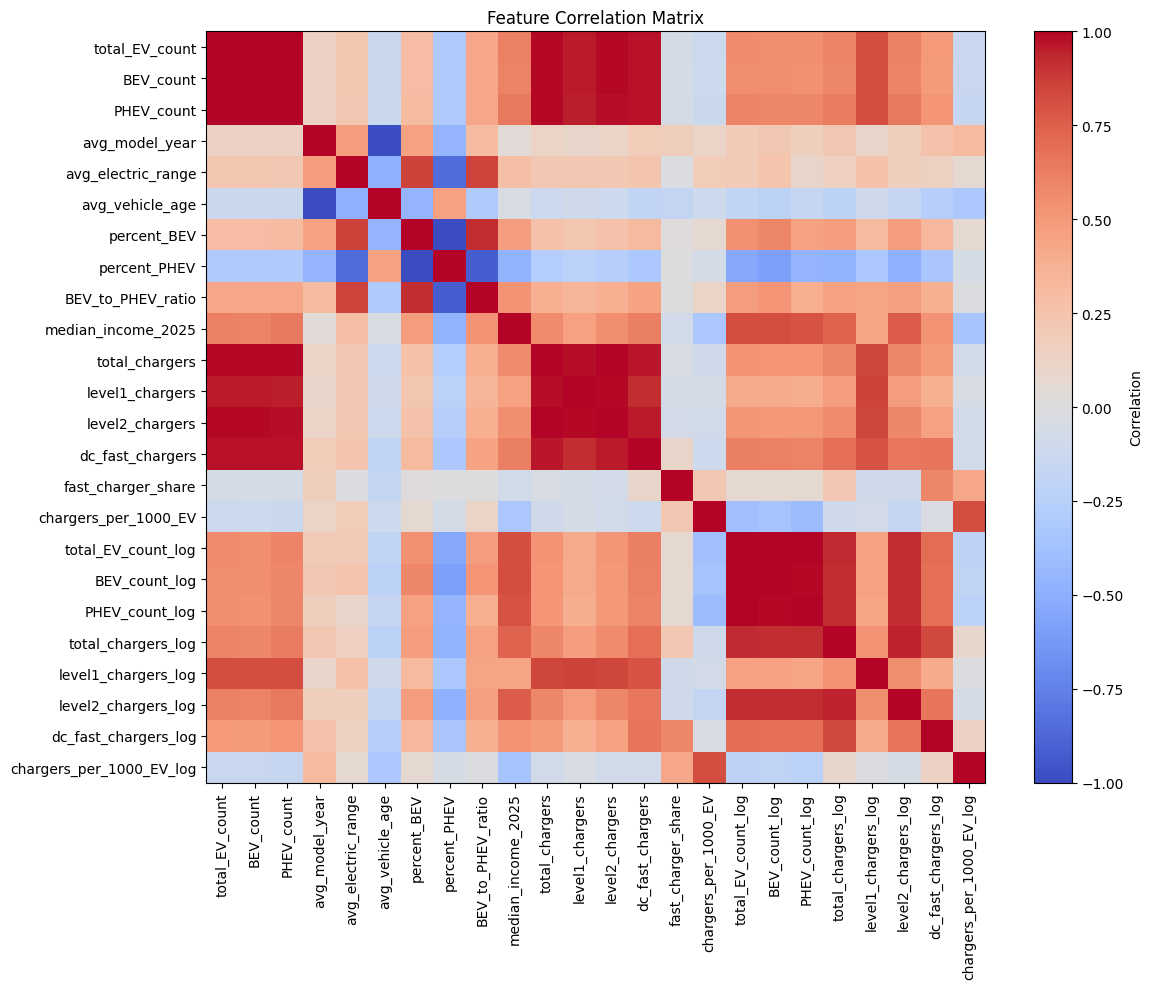

In [8]:
# Correlation matrix
corr = X.corr()

# Plot
plt.figure(figsize=(12,10))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Strong red block among EV + charger counts
(total_EV_count, BEV_count, PHEV_count, charger variables, and log versions)
- counties with more EVs generally have more chargers and infrastructure.
Raw and log variables are strongly correlated
- expected and confirms the log transform preserved information while reducing skew.
Behavioral variables separate somewhat
(percent_BEV, percent_PHEV, BEV_to_PHEV_ratio)
- these are capturing adoption preference rather than county size
Vehicle age vs model year show inverse relationship
- expected since age derives from model year.

Use the log-transformed dataset only for skewed count variables

Keep:

Non-count / behavioral features
- avg_model_year
- avg_electric_range
- avg_vehicle_age
- percent_BEV
- percent_PHEV
- BEV_to_PHEV_ratio
- median_income_2025
- fast_charger_share

Use log versions only for skewed counts:
- total_EV_count_log
- BEV_count_log
- PHEV_count_log
- total_chargers_log
- level1_chargers_log
- level2_chargers_log
- dc_fast_chargers_log
- chargers_per_1000_EV_log

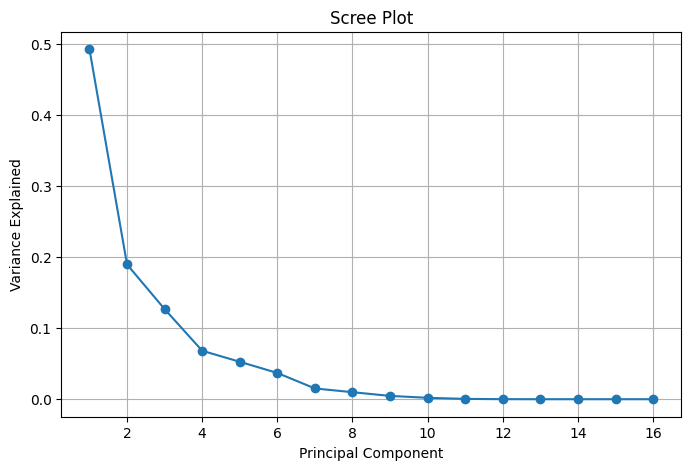

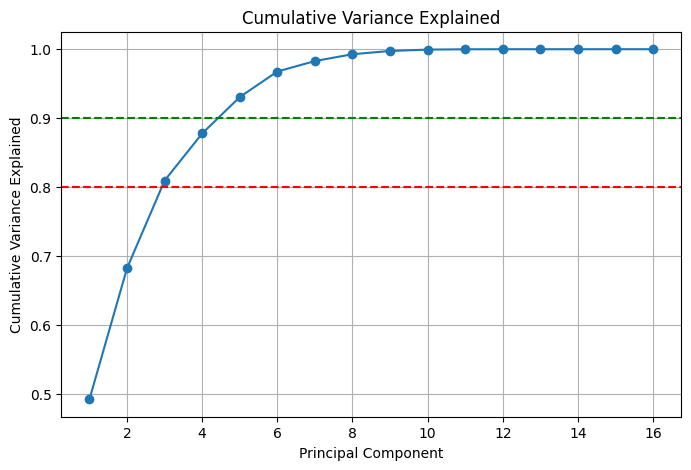

[0.49297936 0.68279128 0.8097188  0.87797345 0.93071578 0.96769982
 0.98286404 0.99277338 0.9974378  0.99944257 0.99991298 0.9999958
 0.99999989 0.99999997 1.         1.        ]


In [9]:
# Final PCA feature set
pca_features = [
    'avg_model_year',
    'avg_electric_range',
    'avg_vehicle_age',
    'percent_BEV',
    'percent_PHEV',
    'BEV_to_PHEV_ratio',
    'median_income_2025',
    'fast_charger_share',
    'total_EV_count_log',
    'BEV_count_log',
    'PHEV_count_log',
    'total_chargers_log',
    'level1_chargers_log',
    'level2_chargers_log',
    'dc_fast_chargers_log',
    'chargers_per_1000_EV_log'
]

X_pca = county_log[pca_features]

# Standardize again for PCA safety
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# PCA
pca = PCA()
pca.fit(X_scaled)

# Variance explained
explained = pca.explained_variance_ratio_
cum_var = np.cumsum(explained)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

# Cumulative variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.80, color='red', linestyle='--')
plt.axhline(0.90, color='green', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained')
plt.grid(True)
plt.show()

print(cum_var)

PC1 explains ~49% of variance

This is large and suggests there is one dominant underlying pattern
Most likely this reflects overall EV adoption + infrastructure scale (high EV counties vs low EV counties)

PC2 explains ~19%

Combined with PC1 this explains ~68%.

PC3 adds ~13%

Together:
PC1 + PC2 + PC3 ~ 81%
This crosses the 80% threshold used

PC5 gets us above ~93%

But after PC3 the scree plot starts flattening
That “elbow” around 3-4 PCs is all we need

In [10]:
# PCA with 3 components
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

# Put PCs into dataframe
pca_df = pd.DataFrame(
    X_pca3,
    columns=['PC1', 'PC2', 'PC3']
)

pca_df['county'] = counties.values

print(pca3.explained_variance_ratio_)
pca_df.head()

[0.49297936 0.18981192 0.12692752]


,PC1,PC2,PC3,county
0,-1.833443,2.401609,2.138565,ADAMS
1,-3.126324,0.052020,-0.844782,ASOTIN
2,1.086439,-0.807701,0.228506,BENTON
3,2.834057,1.761989,-0.007681,CHELAN
4,0.007377,-1.466995,0.773403,CLALLAM


In [11]:
# PCA loadings
loadings = pd.DataFrame(
    pca3.components_.T,
    columns=['PC1','PC2','PC3'],
    index=pca_features
)

loadings

,PC1,PC2,PC3
avg_model_year,0.140318,0.385080,0.243554
avg_electric_range,0.184324,0.408595,-0.250759
avg_vehicle_age,-0.140318,-0.385080,-0.243554
percent_BEV,0.277103,0.288189,-0.192814
percent_PHEV,-0.276719,-0.288545,0.193444
BEV_to_PHEV_ratio,0.265153,0.239750,-0.247237
median_income_2025,0.283795,-0.194603,-0.154500
fast_charger_share,0.035470,0.074574,0.539276
total_EV_count_log,0.327118,-0.194118,0.026663
BEV_count_log,0.332953,-0.166055,0.014648


PC1 (~49%)

This looks like an overall EV adoption + infrastructure scale component

High positive loadings:
total_EV_count_log = 0.327
BEV_count_log = 0.333
PHEV_count_log = 0.312
total_chargers_log = 0.319
level2_chargers_log = 0.313
median_income_2025 = 0.284
percent_BEV = 0.277
BEV_to_PHEV_ratio = 0.265

High PC1 counties -> more EVs, more chargers, somewhat wealthier, stronger BEV adoption.

PC2 (~19%)

This looks like a vehicle technology / modernization component

Large positive:
avg_electric_range = 0.409
avg_model_year = 0.385
percent_BEV = 0.288
chargers_per_1000_EV_log = 0.251

Large negative:
avg_vehicle_age = -0.385
percent_PHEV = -0.289

High PC2 counties -> newer vehicles, longer ranges, more BEVs, less dependence on PHEVs.

This looks like a modern EV adoption pattern.

PC3 (~13%)

This looks like an fast-charging / infrastructure density component.

Largest loadings:
fast_charger_share = 0.539
chargers_per_1000_EV_log = 0.429
dc_fast_chargers_log = 0.370

High PC3 counties -> stronger charging accessibility and DC fast-charging presence.

This directly relates to the question of where infrastructure is supporting adoption vs lagging.

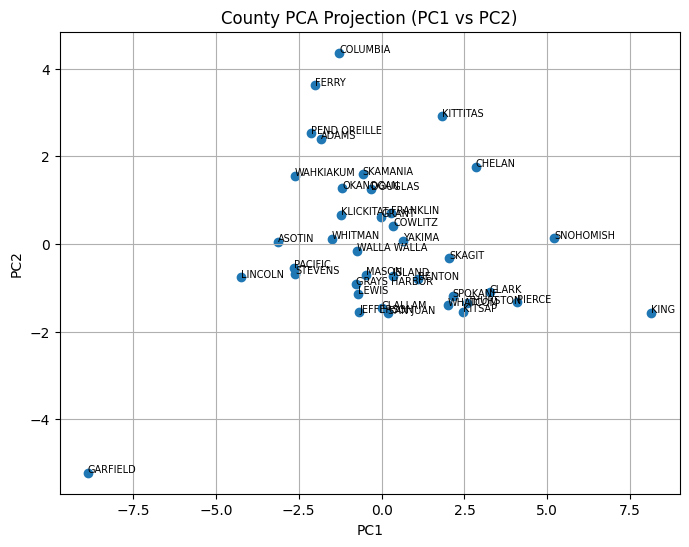

In [12]:
# PCA scatterplot
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2']
)

# Label counties
for i, county in enumerate(pca_df['county']):
    plt.text(
        pca_df['PC1'][i],
        pca_df['PC2'][i],
        county,
        fontsize=7
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('County PCA Projection (PC1 vs PC2)')
plt.grid(True)
plt.show()

1. Most counties cluster near the center

A lot of counties overlap around PC1 ~ 0-3 and PC2 ~ -1 to 1.

That suggests many counties have similar overall EV adoption and infrastructure profiles, which means clustering may reveal a few broad groups rather than every county being unique

2. There are several clear outliers

A few counties stand apart:
- KING -> very high PC1
Likely reflects large EV counts and charger infrastructure.
- GARFIELD -> very negative PC1 and PC2
Likely a very low-adoption / low-infrastructure county.
- COLUMBIA and FERRY -> high PC2
Suggests unusual vehicle mix or modernization pattern compared with most counties.
- CHELAN / KITTITAS / SNOHOMISH also separate somewhat.

# K-means clustering

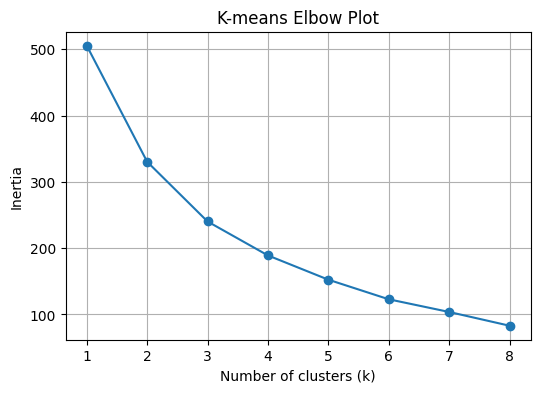

In [13]:
# Use PCA coordinates for clustering
X_cluster = pca_df[['PC1', 'PC2', 'PC3']]

# Elbow method
inertia = []

for k in range(1, 9):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,9), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('K-means Elbow Plot')
plt.grid(True)
plt.show()

The elbow appears around k = 3-4

- Big drop from 1 -> 2 -> 3
- Still some improvement to 4
- After 4, the curve starts flattening and gains become smaller

So the data likely contains about 3 or 4 meaningful groups.

Since we are trying to interpret EV adoption patterns across counties and compare methods,  test k = 3 first, then compare to hierarchical clustering

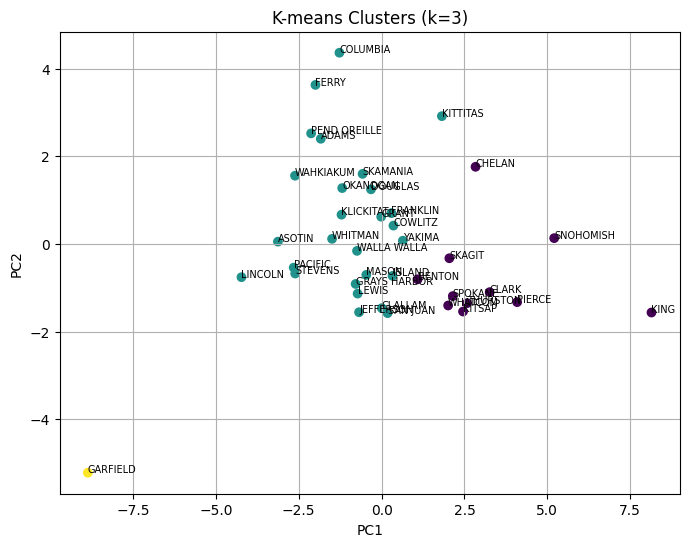

,county,cluster
3,CHELAN,0
2,BENTON,0
5,CLARK,0
28,SKAGIT,0
26,PIERCE,0
31,SPOKANE,0
17,KITSAP,0
16,KING,0
30,SNOHOMISH,0
33,THURSTON,0


In [14]:
# K-means with k=3
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster)

# Add cluster labels
pca_df['cluster'] = clusters

# Plot clusters
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster']
)

# Label counties
for i, county in enumerate(pca_df['county']):
    plt.text(
        pca_df['PC1'][i],
        pca_df['PC2'][i],
        county,
        fontsize=7
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clusters (k=3)')
plt.grid(True)
plt.show()

# View county assignments
pca_df[['county','cluster']].sort_values('cluster')

**Cluster 0 (purple)**

This looks like the high EV adoption / infrastructure cluster

Includes:

- KING
- SNOHOMISH
- CLARK
- SPOKANE
- PIERCE
- KITSAP
- THURSTON
- WHATCOM
- BENTON
- SKAGIT
- CHELAN

These counties sit farther right on PC1, which matches what PCA suggested earlier. Based on the loadings, PC1 was strongly associated with:

- EV counts
- charger counts
- BEV/PHEV totals
- infrastructure variables
- income to some degree

So this cluster likely represents more urbanized or infrastructure-heavy counties with stronger EV adoption

**Cluster 1 (teal)**

This is the majority / moderate adoption cluster

Most counties fall here

These appear to have:

- moderate EV adoption
- moderate infrastructure
- more typical county profiles

This makes sense because earlier we saw most counties grouped near the center of PCA space

**Cluster 2 (yellow)**

This is GARFIELD alone.

K-means isolated Garfield because it is an extreme outlier in PCA space.

That likely means:

- very low EV totals
- sparse infrastructure
- distinctly different profile

# Hierarchical clustering

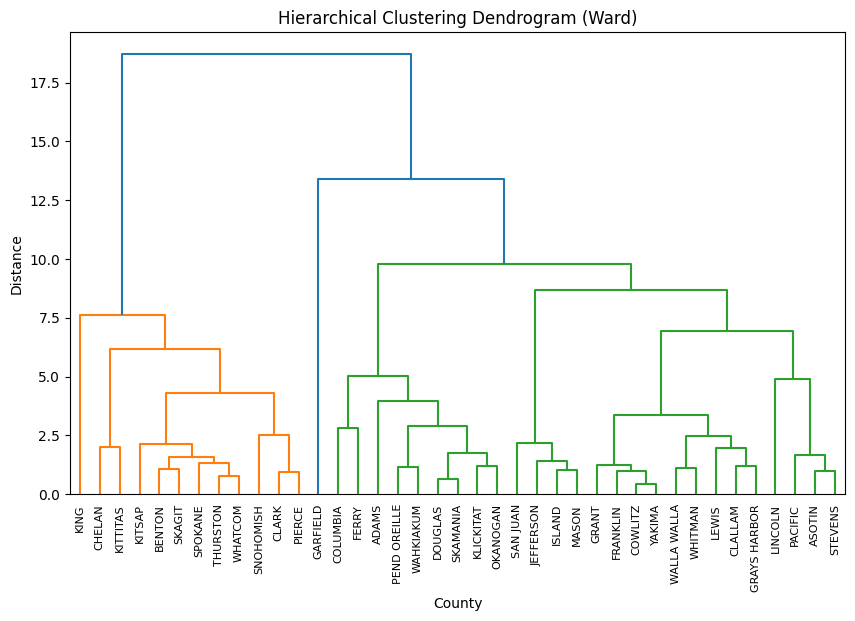

In [15]:
# Ward linkage
Z = linkage(X_cluster, method='ward')

plt.figure(figsize=(10,6))
dendrogram(
    Z,
    labels=pca_df['county'].values,
    leaf_rotation=90
)

plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.xlabel('County')
plt.ylabel('Distance')
plt.show()

The same high-adoption counties cluster together

On the left (orange branch) we see:

- KING
- CHELAN
- KITTITAS
- KITSAP
- BENTON
- SKAGIT
- SPOKANE
- THURSTON
- WHATCOM
- SNOHOMISH
- CLARK
- PIERCE

This overlaps strongly with the K-means Cluster 0 group.

1. Garfield is again unusual

GARFIELD joins the tree at a relatively large distance.

This agrees with K-means isolating it as its own cluster and suggests Garfield is a real outlier, not a clustering artifact.

2. Most counties form a broader moderate group

The large green branch contains most remaining counties.

This matches the PCA and K-means story:

- one higher-adoption / infrastructure group
- one broader moderate group
- one unusual county

The methods are converging on a similar interpretation.

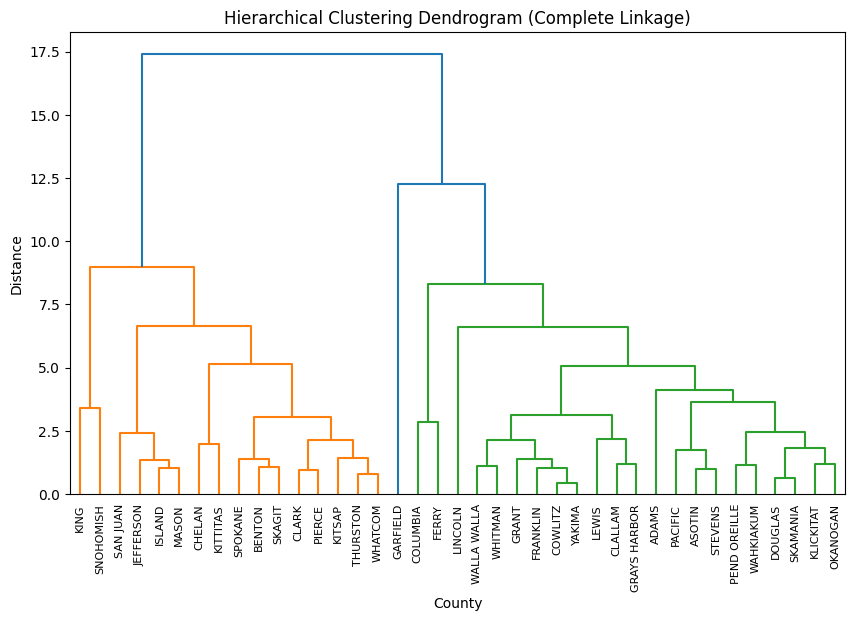

In [16]:
# Complete linkage
Z_complete = linkage(X_cluster, method='complete')

plt.figure(figsize=(10,6))
dendrogram(
    Z_complete,
    labels=pca_df['county'].values,
    leaf_rotation=90
)

plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('County')
plt.ylabel('Distance')
plt.show()

Both methods show:

A higher-adoption / infrastructure-heavy cluster containing counties like:
- KING
- SNOHOMISH
- CHELAN
- KITSAP
- BENTON
- CLARK
- PIERCE
- THURSTON

 A broader moderate-adoption group containing most counties.

 GARFIELD behaving unusually and joining later than many counties.

Differences:

Complete linkage uses the largest pairwise distance when forming clusters

Result:

- more sensitive to separation
- creates tighter cluster boundaries
- slightly different ordering and merges

We see this with counties like:

- JEFFERSON
- MASON
- FERRY
- COLUMBIA

which shift somewhat compared with Ward

Washington counties do not transition to EV adoption uniformly. Multiple methods consistently identify a higher-adoption/infrastructure cluster, a broader moderate-adoption group, and one particularly distinct county.

In [17]:
# Cut Ward dendrogram into 3 clusters
ward_clusters = fcluster(
    Z,
    3,
    criterion='maxclust'
)

pca_df['ward_cluster'] = ward_clusters

# View assignments
pca_df[['county', 'cluster', 'ward_cluster']].sort_values('ward_cluster')

,county,cluster,ward_cluster
3,CHELAN,0,1
2,BENTON,0,1
5,CLARK,0,1
28,SKAGIT,0,1
26,PIERCE,0,1
18,KITTITAS,1,1
17,KITSAP,0,1
16,KING,0,1
30,SNOHOMISH,0,1
31,SPOKANE,0,1


K-means and Ward hierarchical clustering are giving nearly the same structure.

High adoption / infrastructure group

These counties stay together across both methods:

- KING
- SNOHOMISH
- CHELAN
- BENTON
- CLARK
- SKAGIT
- PIERCE
- KITSAP
- SPOKANE
- THURSTON
- WHATCOM

This suggests a stable high-adoption / stronger-infrastructure cluster

Moderate / typical counties

Most counties remain together in:

- K-means cluster 1
- Ward cluster 2

This means the majority of Washington counties share a more moderate EV profile

Again, consistent with PCA and the dendrogram

Garfield remains isolated

K-means -> Cluster 2
Ward -> Cluster 3

Both methods separate Garfield

That strongly suggests Garfield is a true structural outlier, likely reflecting extremely low EV adoption and infrastructure rather than a modeling artifact